$$\Huge\text{Examen de Física Computacional}$$

$$\Large\text{Curso 2024-2025}$$

$$\Large\text{Convocatoria de Diciembre}\quad \text{17.12.2024}$$

<hr style="border:1px solid gray"> </hr>


## Nombre: Germán Cousillas Martínez

## DNI: 79124779H

## Grupo: B

<hr style="border:1px solid gray"> </hr>

# Cuestiones generales


* La **duración** del examen es de **2 horas**.


   
* El **código** debe ser **legible** y estar bien documentado.   
  El alumno deberá incluir los **comentarios** adecuados para explicar lo que pretende conseguir con su código.   
  La legibilidad y claridad del código quedará reflejada en la evaluación del examen.




* Para realizar este examen se podrá **recurrir a cualquier fuente**, tanto física como digital, pero **no** a ningún tipo de **inteligencia artificial**.  
  El profesor se guarda el derecho de **convocar al alumno para discutir** aquellos aspectos de su **código** que considere oportunos.


*  El examen debe representar el **trabajo individual** del alumno.   
   No está permitido discutir o comentar ningún aspecto con otros compañeros.
   
   

*  El examen se deberá **enviar** en formato .ipynb o .py a través del **campus virtual**.   
   Solo en casos completamente imprescindibles se podrá aportar en una memoria usb.
   
 
*  Es responsabilidad del alumno enviar al final del examen el archivo requerido.   
   Una vez finalizado el examen no se aceptarán correcciones ni cambios en el archivo.

# Ejercicio 1: Representado funciones complejas [1 pt]

* Dada la función compleja:
 
  $$f(z)=\displaystyle\sin\left(\frac{1}{z}\right),\quad z\in\mathbb{C},$$

  representar el valor de su parte real e imaginaria en el dominio del plano complejo definido por:
  
  $$-0.1\le\Re \text{e}\,z\le 0.1,\qquad-0.1\le\Im\text{m}\,z\le 0.1,$$ 
  
  usando un retículo de $1000\times 1000$ puntos.

**Ayuda:** 

* Es posible que os aparezca un aviso de **overflow** al evaluar vuestra función en algún punto. Podéis ignorarlo.

* Dado un número complejo $\bf z$, su parte real e imaginaria se pueden obtener usando $\bf z.real$ y $\bf z.imag$, respectivamente.

* Se recomienda usar  **vmax=1** y **vmin=-1** en ambas representaciones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-0.1,0.1,1000)
y = np.linspace(-0.1,0.1,1000)

X, Y = np.meshgrid(x, y)
Z = X+1j*Y # Generamos el retículo del plano complejo solicitado

f = lambda z: np.sin(1/z)

val = f(Z) # Evaluamos la función en el retículo. Haciéndolo así nos ahorramos una evaluación después

/tmp/ipykernel_24445/3071566434.py:10: RuntimeWarning: overflow encountered in sin
  f = lambda z: np.sin(1/z)


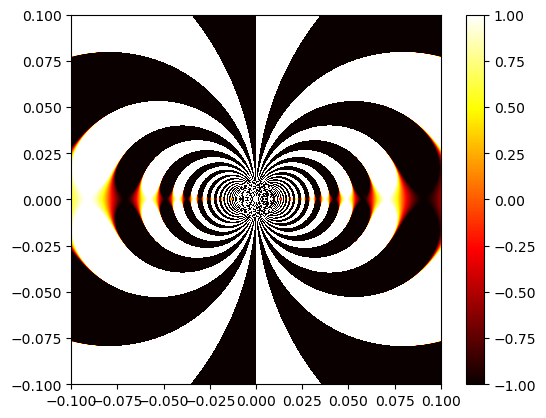

In [2]:
# Parte real
plt.imshow(np.real(val), extent=[-0.1,0.1,-0.1,0.1], origin="lower", cmap="hot", vmax=1, vmin=-1)
plt.colorbar()
plt.show()

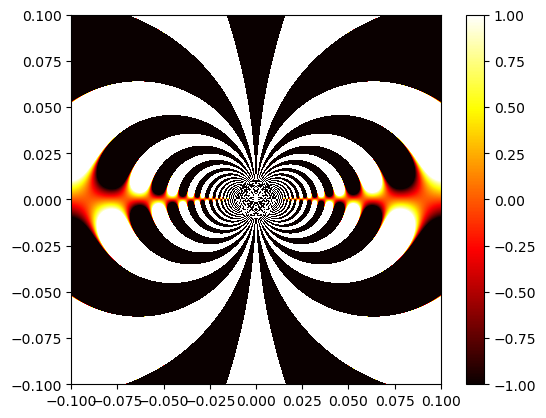

In [3]:
# Parte compleja
plt.imshow(np.imag(val), extent=[-0.1,0.1,-0.1,0.1], origin="lower", cmap="hot", vmax=1, vmin=-1)
plt.colorbar()
plt.show()

# Ejercicio 2: Encontrando ceros de una función compleja [2 pts]


Escribir un programa que, partiendo de un punto inicial $z_0$, encuentre la raíz de la función $1/f(z)$ con una precisión $\epsilon=10^{-5}$.

Ejecutar el programa usando los puntos iniciales:

- $z_0=1+\,i$
- $z_0=1-\,i$
- $z_0=-1+\,i$
- $z_0=-1-\,i$

¿Obtienes le mismos resultado para cada punto inicial? ¿Por qué?

**Nota:** procedemos por el método de la secante en varias variables. Al costo de tener que implementar el método de eliminación Gaussiana para resolver el sistema de ecuaciones lineales al que da lugar el método de Newton-Raphson (cuya única modificación es que ahora el cálculo de las derivadas de la matriz Jacobiana se hacen de forma numérica), podemos evitarnos los problemas de convergencia del punto fijo, que es, $\textit{a priori}$, más sencillo de implementar

In [4]:
# Sust. hacia atrás
import numpy as np

def sust_atras(A, B):
    N = len(B)
    x = np.empty_like(B)
    d = np.diag(A)
    
    for i in range(N-1, -1, -1):
        x[i] = B[i]
        for n in range(i+1, N):
            x[i] -= A[i, n]*x[n]
        x[i] /= d[i]
    return x

In [5]:
# Algoritmo para hacer matriz triang. sup. con pivote

import numpy as np
def make_triang_sup(AB):
    # 1. Ubico elemento máximo y pivoto
    # 2. Divido por pivote toda la fila
    # 3. Resto en cascada multiplicando por la cabeza de cada fila
    
    N = len(AB)
    for i in range(N): # Por cada fila
        col = AB[i:, i] # No puedo tomar como pivote de la fila 2 algo de la fila 1
        pivote = np.max(col)
        ind = np.where(col==pivote)[0][0] + i # No puedo tener en cuenta las filas superiores
        
        # Una vez ubicado el pivote, pivoto fila actual por la de interés
        AB[i,:], AB[ind, :] = AB[ind, :].copy(), AB[i, :].copy()
        
        # Ahora divido por el pivote de la fila
        AB[i,i:] /= pivote
        
        # Finalmente, multiplico por cabeza de cada fila y resto
        for j in range(i+1, N):
            head = AB[j, i]
            AB[j,i:] -= head*AB[i,i:] # Solo resto aquel subconjunto de las filas que es no nulo
        
    return AB

In [6]:
def solveGauss(A, B):
    AB = np.column_stack((A, B))
    triang = make_triang_sup(AB)
    
    A = AB[:,:-1]
    B = AB[:,-1]
    
    return sust_atras(A, B)

In [7]:
# Probamos por el método de la secante
g = lambda z: 1/f(z)

## Que la función se anule implica que Re(g)=0 y que Im(g)=0 al mismo tiempo
# Podemos tratar el problema como uno en dos dimensiones
h=1e-5

f1 = lambda x, y: np.real(g(x+1j*y))
f2 = lambda x, y: np.imag(g(x+1j*y))

J_1x = lambda x, y: (f1(x+h,y)-f1(x-h,y))/(2*h)
J_1y = lambda x, y: (f1(x,y+h)-f1(x,y-h))/(2*h)
J_2x = lambda x, y: (f2(x+h,y)-f2(x-h,y))/(2*h)
J_2y = lambda x, y: (f2(x,y+h)-f2(x,y-h))/(2*h)

def F(r):
    x, y = r
    return np.array([f1(x, y), f2(x, y)], float)

def J(r):
    x, y = r
    return np.array([[J_1x(x, y), J_1y(x, y)], [J_2x(x, y), J_2y(x, y)]], float)

def secante_Nvar(F, J, X0, tol):
    err = 2*tol
    
    while err > tol:
        DX = solveGauss(J(X0), F(X0))
        X1 = X0-DX
        
        err = np.max(np.abs(X1-X0)) # Así me aseguro de que todos están por debajo de la tolerancia requerida
        X0=X1
    
    return X1

**Nota: tal y como está programado el método, el primer elemento del vector es la parte real y la segunda es la imaginaria**

$$z_0=1+i$$

In [8]:
root1 = secante_Nvar(F, J, [1,1], 1e-5)
print(root1)

[-1.47212085e-05  3.35356785e-03]


$$z_0=1-i$$

In [9]:
root2 = secante_Nvar(F, J, [1,-1], 1e-5)
print(root2)

[-1.47212085e-05 -3.35356785e-03]


$$z_0=-1+i$$

In [10]:
root3 = secante_Nvar(F, J, [-1,1], 1e-5)
print(root3)

[1.47212085e-05 3.35356785e-03]


$$z_0=-1-i$$

In [11]:
root4 = secante_Nvar(F, J, [-1,-1], 1e-5)
print(root4)

[ 1.47212085e-05 -3.35356785e-03]


**Nota:** antes de responder a la pregunta de este apartado, cabe comprobar que, efectivamente, los resultados a los que llegamos son ceros de la función $g(z)=\frac{1}{f(z)}$

In [12]:
val1 = g(root1[0]+1j*root1[1])
val2 = g(root2[0]+1j*root2[1])
val3 = g(root3[0]+1j*root3[1])
val4 = g(root4[0]+1j*root4[1])

In [14]:
print(f"Evaluaciones:\n g(1+i)={val1}\n g(1-i)={val2}\n g(-1+i)={val3}\n g(-1-i)={val4}")

Evaluaciones:
 g(1+i)=(-6.11283601312876e-130+1.6382796046509526e-130j)
 g(1-i)=(-6.112836013153476e-130-1.6382796046587881e-130j)
 g(-1+i)=(6.112836013153476e-130+1.6382796046587881e-130j)
 g(-1-i)=(6.11283601312876e-130-1.6382796046509526e-130j)


Comprobamos que, efectivamente, hemos alcanzado varios ceros de la función. El motivo por el que no se obtiene el mismo resultado al partir de puntos diferentes es que la función puede tener más de un cero, y la convergencia de todo método numérico depende, entre otros factores, de la proximidad del punto inicial al resultado que se debe obtener. Esto provoca que diferentes puntos de partida den lugar a diferentes resultados, o incluso que diverjan.

# Ejercicio 3: Probando el teorema de Cauchy  [3 pts]

Calcular la integral

$$\frac{1}{2\pi i}\int_D{\text{d}z\,f(z)},$$

usando los contornos:

1. $D\equiv z \in {\mathbb C}\;\big\vert\; z=\vert z\vert\text{e}^{i\theta},\;\text{con}\; \vert z\vert = R,\;\text{y}\;\theta=[0,2\pi),\:$  
   
    es decir, un contorno circular en el plano complejo centrado en $z=0$ de radio $R$ en sentido anti horario.  
   
   Considerar $R=1$, $2$ y $3$.  
      
   
2. $D \equiv z \in {\mathbb C}\;\big\vert\; z=\left\{\begin{matrix} z=\;\;x - i,\quad\;\; x\in[-1,1] \\ z=1+i\,y,\quad \;\;y\in[-1,1]\\z=-x + i,\quad \;\;x\in[-1,1] \\ z=-1-i\,y,\quad y\in[-1,1] \end{matrix}\right.,\;$ 
   
   es decir, un cuadrado centrado en $z=0$ de lado $L=2$ en sentido antihorario.


¿Qué obtienes en cada caso? ¿Por qué?                           

## Apartado 1

**La integral se reduce a calcular:**

$$I=\frac{1}{2\pi i}\oint f(z)dz$$

con $z=Re^{i\theta} \Longrightarrow dz = izd\theta$

Por tanto:

$$I = \frac{1}{2\pi}\int_0^{2\pi}Re^{i\theta}\sin\left(\frac{1}{R}e^{-i\theta}\right)d\theta$$

**Caso 1: R=1**

In [1]:
import numpy as np
from gaussxw import gaussxwab

R = 1
g = lambda theta: 1/(2*np.pi)*R*np.exp(1j*theta) * np.sin(1/R*np.exp(-1j*theta))
N=1000

theta, w = gaussxwab(N, 0, 2*np.pi)

I = np.sum(w*g(theta))
print(I)

(1.0000000000000002-3.469446951953614e-18j)


**Caso 2: R=2**

In [2]:
R = 2
g = lambda theta: 1/(2*np.pi)*R*np.exp(1j*theta) * np.sin(1/R*np.exp(-1j*theta))
N=1000

theta, w = gaussxwab(N, 0, 2*np.pi)

I = np.sum(w*g(theta))
print(I)

(1.0000000000000002+0j)


**Caso 3: R=3**

In [5]:
R = 3
g = lambda theta: 1/(2*np.pi)*R*np.exp(1j*theta) * np.sin(1/R*np.exp(-1j*theta))
N=1000

theta, w = gaussxwab(N, 0, 2*np.pi)

I = np.sum(w*g(theta))
print(I)

(1-4.336808689942018e-18j)


## Apartado 2

**Nota:** para el cálculo de esta segunda integral, podemos subdividir la curva sobre la que estamos integrando en cuatro segmentos distintos del plano complejo. De hecho, esto ya se hace explícitamente en la parametrización del enunciado. Haciendo ahora $z=x+iy$, tenemos que:

$$I=I_1+I_2+I_3+I_4$$

donde:

- $I_1=\frac{1}{2\pi i}\int_{-1}^1\sin\left(\frac{1}{x-i}\right)dx$
- $I_2 = \frac{1}{2\pi}\int_{-1}^1 \sin\left(\frac{1}{1+iy}\right)dy$
- $I_3=\frac{1}{2\pi i}\int_{1}^{-1}\sin\left(\frac{1}{x+i}\right)dx=-\frac{1}{2\pi i}\int_{-1}^{1}\sin\left(\frac{1}{x+i}\right)dx$
- $I_4 = \frac{1}{2\pi}\int_{1}^{-1} \sin\left(\frac{1}{-1+iy}\right)dy=-\frac{1}{2\pi}\int_{-1}^{1} \sin\left(\frac{1}{-1+iy}\right)dy$

In [6]:
import numpy as np
from gaussxw import gaussxw

f = lambda z: np.sin(1/z)

N = 1000
x, w = gaussxw(N)

f1 = lambda x: 1/(2*np.pi*1j) * np.sin(1/(x-1j))
f2 = lambda y: 1/(2*np.pi) * np.sin(1/(1+1j*y))
f3 = lambda x: -1/(2*np.pi*1j) * np.sin(1/(x+1j))
f4 = lambda y: -1/(2*np.pi) * np.sin(1/(-1+1j*y))

I1 = np.sum(w*f1(x))
I2 = np.sum(w*f2(x))
I3 = np.sum(w*f3(x))
I4 = np.sum(w*f4(x))

I = I1+I2+I3+I4

print(I)

(1.0000000000000002+0j)


**Nota:** se obtiene lo mismo independientemente de la curva cerrada empleada para calcular la integral. Seguramente el resultado analítico de la integral se podría obtener con el teorema del residuo, y el argumento para que ambas integrales den lo mismo implica que las dos curvas cerradas consideradas encierran las mismas singularidades de la función, dando lugar al mismo residuo y por tanto al mismo valor de la integral.

# Ejercicio 4: Orbitando un agujero negro [4 pts]


En presencia de un objeto muy masivo de masa $M$, tal como un agujero negro, las ecuaciones de la gravitación Newtoniana sufren una corrección debida a la relatividad general. Tomando unidades naturales y normalizando al llamado radio de Schwarzschild, la fuerza ejercida por dicho objeto sobre una partícula de masa $m$ despreciable viene dada por:

$${\bf F}^\text{rel}({\bf r})=-\frac{m\,M}{r^3}\left(1+3\frac{\vert {\bf r}\times {\bf v}\vert^2}{r^2}\right)\,{\bf r},$$


donde $r$ es la distancia al centro del agujero negro.

* Asumiendo que la partícula está inicialmente en el punto ${\bf r_0}=(0, 10)$, tomando $M=1/2$ y usando la segunda ley de Newton, representar las órbitas de la partícula con las condiciones iniciales:<p>

     1. ${\bf v_0}=(0.1845, 0)$ para un tiempo máximo $t_\text{max}=102.83$,
 
     2. ${\bf v_0}=(0.2, 0)$ para un tiempo máximo $t_\text{max}=5000$,
  
     3. ${\bf v_0}=(0.2, -0.25)$ para un tiempo máximo $t_\text{max}=100$, 
 
   usando en todos los casos $N=10000$ pasos temporales. 

   ¿Qué tipo de órbitas obtienes?<p>

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Datos del problema
M=1/2
r0=10
N=10000

## Apartado 1

In [8]:
# Procedemos por RK4

def F(u):
    x, y, vx, vy = u
    r = np.array([x, y])
    v = np.array([vx, vy])
    
    mod_r = np.linalg.norm(r)
    
    a = -M/mod_r**3 * ( 1 + 3*np.linalg.norm(np.cross(r,v))**2/mod_r**2 )*r
    
    return np.array([vx, vy, a[0], a[1]], float)
    

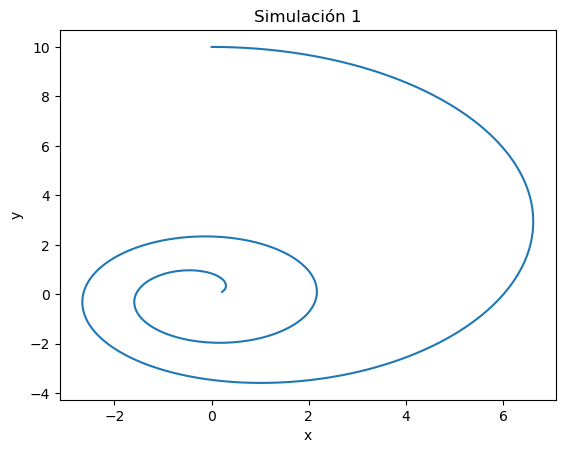

In [9]:
t0=0
t_max = 102.83
h = t_max/N
tp = np.linspace(t0,t_max, N)

# Condiciones iniciales
u = np.array([0,10,0.1845,0], float)
xp1_rel = []
yp1_rel = []
U1_rel = []
E1_rel = []

for t in tp:
    x, y, vx, vy = u
    xp1_rel.append(x)
    yp1_rel.append(y)
    r = np.array([x, y])
    v = np.array([vx,vy])
    mod_r = np.linalg.norm(r)
    
    U = -M/mod_r + np.linalg.norm(np.cross(r,v))**2/(2*mod_r**2) - M*np.linalg.norm(np.cross(r,v))**2/mod_r**3
    U1_rel.append(U)
    
    T = 1/2*np.dot(r,v)**2/mod_r**2
    E1_rel.append(U+T)
    
    k1 = h*F(u)
    k2 = h*F(u+k1/2)
    k3 = h*F(u+k2/2)
    k4 = h*F(u+k3)
    
    u+= 1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(xp1_rel, yp1_rel)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulación 1")
plt.show()

**Nota:** con estas condiciones iniciales, el objeto no tiene suficiente energía como para orbitar el agujero negro y acaba siendo acretado por este. Esto es, el objeto pasa a formar parte del disco de acreción del agujero negro. Si se hiciera esta misma simulación con un número muy elevado de partículas, se podría simular la acreción de materia de los agujeros negros. Si además se permitiera la radiación de sincrotrón, veríamos la radiación típica emitida por estos objetos.

Una forma interesante de continuar con esta simulación sería permitir el bombeo de momento angular hacia las regiones exteriores del disco de acreción a través del campo magnético del sistema, dando lugar a los característicos jets de los gujeros negros. Entonces, la partícula estudiada caería inicialmente en una trayectoria espiral hasta finalmente ser eyectada de vuelta al medio interestelar.

## Apartado 2

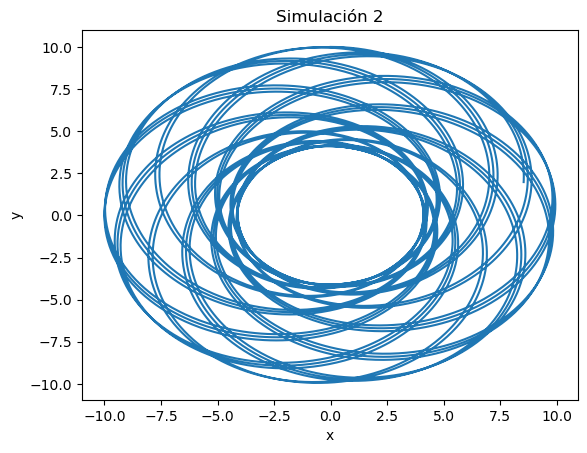

In [10]:
t0=0
t_max = 5000
h = t_max/N
tp = np.linspace(t0,t_max, N)

# Condiciones iniciales
u = np.array([0,10,0.2,0], float)
xp2_rel = []
yp2_rel = []
U2_rel = []
E2_rel = []

for t in tp:
    x, y, vx, vy = u
    xp2_rel.append(x)
    yp2_rel.append(y)
    r = np.array([x, y])
    v = np.array([vx,vy])
    mod_r = np.linalg.norm(r)
    
    U = -M/mod_r + np.linalg.norm(np.cross(r,v))**2/(2*mod_r**2) - M*np.linalg.norm(np.cross(r,v))**2/mod_r**3
    U2_rel.append(U)
    
    T = 1/2*np.dot(r,v)**2/mod_r**2
    E2_rel.append(U+T)
    
    k1 = h*F(u)
    k2 = h*F(u+k1/2)
    k3 = h*F(u+k2/2)
    k4 = h*F(u+k3)
    
    u+= 1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(xp2_rel, yp2_rel)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulación 2")
plt.show()

**Nota:** con estas condiciones iniciales, la órbita del cuerpo parece ser acotada. En principio, es difícil establecer si es o no cerrada. Para una discusión más en profundidad, se refiere al lector a la última sección de este ejercicio.

## Apartado 3

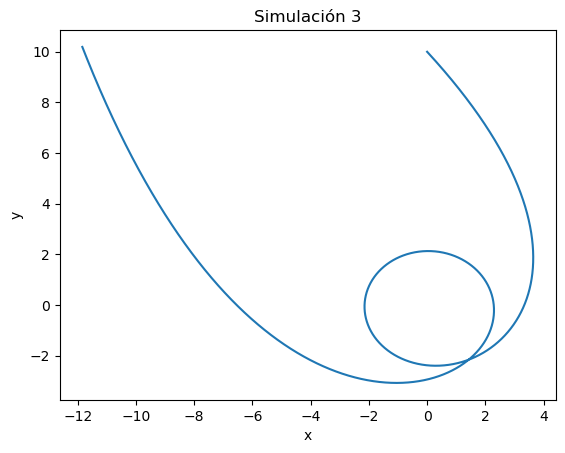

In [11]:
t0=0
t_max = 100
h = t_max/N
tp = np.linspace(t0,t_max, N)

# Condiciones iniciales
u = np.array([0,10,0.2,-0.25], float)
xp3_rel = []
yp3_rel = []
U3_rel = []
E3_rel = []

for t in tp:
    x, y, vx, vy = u
    xp3_rel.append(x)
    yp3_rel.append(y)
    r = np.array([x, y])
    v = np.array([vx,vy])
    mod_r = np.linalg.norm(r)
    
    U = -M/mod_r + np.linalg.norm(np.cross(r,v))**2/(2*mod_r**2) - M*np.linalg.norm(np.cross(r,v))**2/mod_r**3
    U3_rel.append(U)
    
    T = 1/2*np.dot(r,v)**2/mod_r**2
    E3_rel.append(U+T)
    
    k1 = h*F(u)
    k2 = h*F(u+k1/2)
    k3 = h*F(u+k2/2)
    k4 = h*F(u+k3)
    
    u+= 1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(xp3_rel, yp3_rel)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulación 3")
plt.show()

**Nota:** con estas condiciones iniciales, el objeto es demasiado energético como para ser retenido en una órbita en torno al agujero negro y acaba saliendo despedido, no sin antes efectuar una vuelta completa en torno al agujero. La posición de este último se puede determinar como el baricentro de la órbita circular

* Obtener de nuevo las tres órbitas en el límite clásico, en el que la fuerza se reduce a:

    $${\bf F}^\text{clas}({\bf r})=-\frac{m\,M}{r^3}\,{\bf r},$$

    y representarlas junto a las órbitas relativistas. ¿Qué resultado observas?<p>

In [12]:
import numpy as np
import matplotlib.pyplot as plt
# Datos del problema
M=1/2
r0=10
N=10000

## Apartado 1

In [13]:
# Procedemos por RK4

def F(u):
    x, y, vx, vy = u
    r = np.array([x, y])
    
    mod_r = np.linalg.norm(r)
    
    a = -M/mod_r**3*r
    
    return np.array([vx, vy, a[0], a[1]], float)

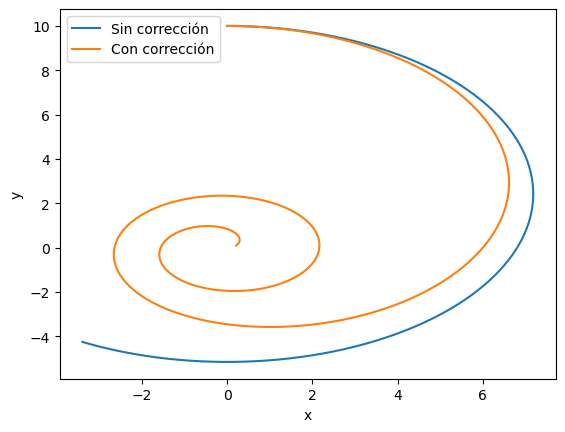

In [14]:
t0=0
t_max = 102.83
h = t_max/N
tp = np.linspace(t0,t_max, N)

# Condiciones iniciales
u = np.array([0,10,0.1845,0], float)
xp1_newt = []
yp1_newt = []
U1_newt = []
E1_newt = []

for t in tp:
    x, y, vx, vy = u
    xp1_newt.append(x)
    yp1_newt.append(y)
    r = np.array([x, y])
    v = np.array([vx,vy])
    mod_r = np.linalg.norm(r)
    
    U = -M/mod_r + np.linalg.norm(np.cross(r,v))**2/(2*mod_r**2)
    U1_newt.append(U)
    
    T = 1/2*np.dot(r,v)**2/mod_r**2
    E1_newt.append(U+T)
    
    
    k1 = h*F(u)
    k2 = h*F(u+k1/2)
    k3 = h*F(u+k2/2)
    k4 = h*F(u+k3)
    
    u+= 1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(xp1_newt, yp1_newt, label="Sin corrección")
plt.plot(xp1_rel, yp1_rel, label="Con corrección")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Apartado 2

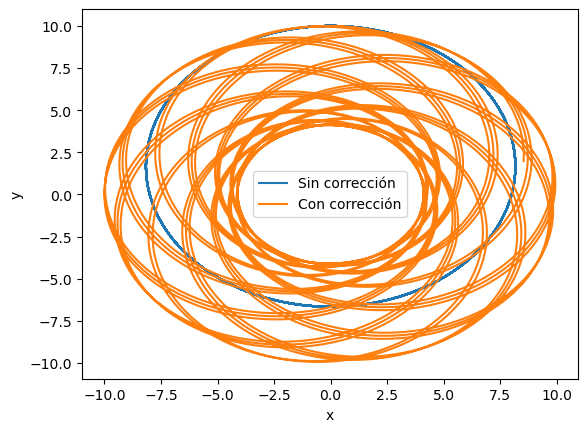

In [15]:
t0=0
t_max = 5000
h = t_max/N
tp = np.linspace(t0,t_max, N)

# Condiciones iniciales
u = np.array([0,10,0.2,0], float)
xp2_newt = []
yp2_newt = []
U2_newt = []
E2_newt = []

for t in tp:
    x, y, vx, vy = u
    xp2_newt.append(x)
    yp2_newt.append(y)
    r = np.array([x, y])
    v = np.array([vx,vy])
    mod_r = np.linalg.norm(r)
    
    U = -M/mod_r + np.linalg.norm(np.cross(r,v))**2/(2*mod_r**2)
    U2_newt.append(U)
    
    T = 1/2*np.dot(r,v)**2/mod_r**2
    E2_newt.append(U+T)
    
    k1 = h*F(u)
    k2 = h*F(u+k1/2)
    k3 = h*F(u+k2/2)
    k4 = h*F(u+k3)
    
    u+= 1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(xp2_newt, yp2_newt, label="Sin corrección")
plt.plot(xp2_rel, yp2_rel, label="Con corrección")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Apartado 3

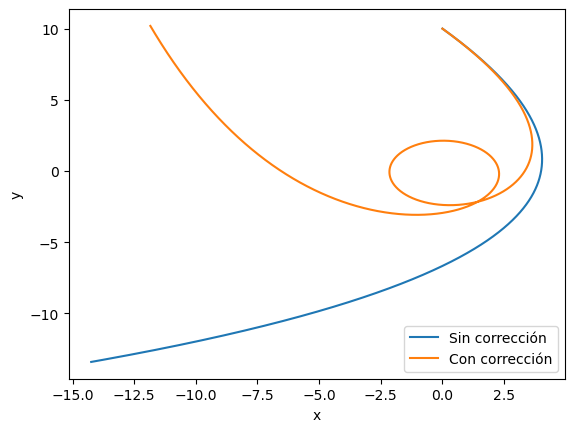

In [16]:
t0=0
t_max = 100
h = t_max/N
tp = np.linspace(t0,t_max, N)

# Condiciones iniciales
u = np.array([0,10,0.2,-0.25], float)
xp3_newt = []
yp3_newt = []
U3_newt = []
E3_newt = []

for t in tp:
    x, y, vx, vy = u
    xp3_newt.append(x)
    yp3_newt.append(y)
    r = np.array([x, y])
    v = np.array([vx,vy])
    mod_r = np.linalg.norm(r)
    
    U = -M/mod_r + np.linalg.norm(np.cross(r,v))**2/(2*mod_r**2)
    U3_newt.append(U)
    
    T = 1/2*np.dot(r,v)**2/mod_r**2
    E3_newt.append(U+T)
    
    k1 = h*F(u)
    k2 = h*F(u+k1/2)
    k3 = h*F(u+k2/2)
    k4 = h*F(u+k3)
    
    u+= 1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(xp3_newt, yp3_newt, label="Sin corrección")
plt.plot(xp3_rel, yp3_rel, label="Con corrección")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

* El movimiento de la partícula es consecuencia del llamado potencial efectivo, que es suma de dos efectos opuestos, la energía potencial, atractiva, y la energía centrífuga, repulsiva. En el caso relativista, el potencial efectivo viene dado por:

    $$U^\text{rel}_\text{eff}({\bf r},{\bf v})=-\frac{M}{r}+\frac{\vert {\bf r}\times {\bf v}\vert^2}{2r^2}-\frac{M\,\vert {\bf r}\times {\bf v}\vert^2}{r^3},$$

    mientras que en el caso clásico se reduce a:

    $$U^\text{clas}_\text{eff}({\bf r},{\bf v})=-\frac{M}{r}+\frac{\vert {\bf r}\times {\bf v}\vert^2}{2r^2}.$$

   Representar en la misma gráfica para cada una de las tres condiciones iniciales el potencial efectivo clásico y relativista.

   Añadir también a la gráfica la energía total de la partícula, tanto clásica como relativista, que en ambos casos es la suma de su potencial efectivo y la energía cinética:

    $$E_\text{cin}({\bf r},{\bf v})=\frac{1}{2}\frac{\vert\,{\bf r}\cdot {\bf v}\,\vert^2}{r^2}.$$

    ¿Puedes explicar a partir de estos resultados cada tipo de órbita?

    **Ayuda:** 

    * Para la primera órbita es conveniente limitar la representación al intervalo $r>1$ utilizando, por ejemplo, las funciones de matplotlib $xlim$ e $ylim$.

## Energías apartado 1

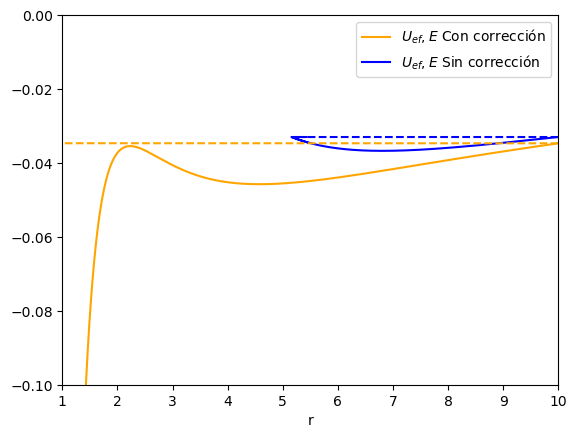

In [17]:
xp1_rel = np.array(xp1_rel)
yp1_rel = np.array(yp1_rel)
xp1_newt = np.array(xp1_newt)
yp1_newt = np.array(yp1_newt)

r_rel = np.sqrt(xp1_rel**2+yp1_rel**2)
r_newt = np.sqrt(xp1_newt**2+yp1_newt**2)

# Potenciales efectivos
plt.plot(r_rel, U1_rel, label="$U_{ef},E$ Con corrección", color="orange")
plt.plot(r_newt, U1_newt, label="$U_{ef},E$ Sin corrección", color="b")

# Energías
plt.plot(r_rel, E1_rel, "--", color="orange")
plt.plot(r_newt, E1_newt, "b--")

plt.ylim(-0.1,0)
plt.xlim(1,10)
plt.xlabel("r")

plt.legend()
plt.show()

**Interpretación de las órbitas a partir de los potenciales efectivos y energías:** observamos que la órbita parece ser cerrada en ambos casos. Sin embargo, en el caso sin corrección vemos que la partícula se encuentra confinada en un pozo de potencial, de modo que la trayectoria será elíptica. En el caso con corrección, la clave de la trayectoria de la partícula se encuentra en que la energía del objeto en este caso está un poco por encima del máximo del potencial, de modo que es capaz de sobrepasarlo y finalmente caer al origen. Esta es la razón por la que vemos una trayectoria en espiral mientras que la dinámica clásica predecía una órbita estable.

## Energías apartado 2

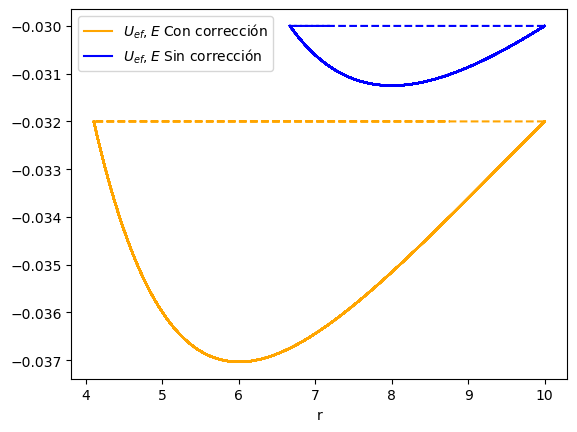

In [21]:
xp2_rel = np.array(xp2_rel)
yp2_rel = np.array(yp2_rel)
xp2_newt = np.array(xp2_newt)
yp2_newt = np.array(yp2_newt)

r_rel = np.sqrt(xp2_rel**2+yp2_rel**2)
r_newt = np.sqrt(xp2_newt**2+yp2_newt**2)

# Potenciales efectivos
plt.plot(r_rel, U2_rel, label="$U_{ef},E$ Con corrección", color="orange")
plt.plot(r_newt, U2_newt, label="$U_{ef},E$ Sin corrección", color="b")

# Energías
plt.plot(r_rel, E2_rel, "--", color="orange")
plt.plot(r_newt, E2_newt, "b--")


plt.legend()
plt.xlabel("r")
plt.show()

**Interpretación de las órbitas a partir de los potenciales efectivos y la energías:** en ambos casos notamos ahora que la partícula se encuentra en un pozo de potencial. Es por esto que en las dos órbitas correspondientes a este gráfico (corregida y sin corregir) la trayectoria es cerrada. No obstante, mientras que la dinámica clásica predice una órbita prácticamente circular (el potencial Kepleriano no es capaz de dar lugar a otro tipo de órbitas cerradas que no sean elípticas), el potencial corregido dota a la partícula de una trayectoria acotada que, sin embargo, no es sencillo determinar si es o no cerrada. $\textit{A priori}$, podría ser cerrada y lo que sucede es, sencillamente, que a la partícula le toma ahora más tiempo y más vueltas alrededor del atractor completar una órbita entera.

Asimismo, la trayectoria de la partícula podría no ser cerrada y ser únicamente acotada, de modo que, invocando la hipótesis ergódica en la región interior a la acotación de la órbita, la partícula acabará recorriendo cada punto de dicha región en un tiempo suficientemente largo.

## Energías apartado 3

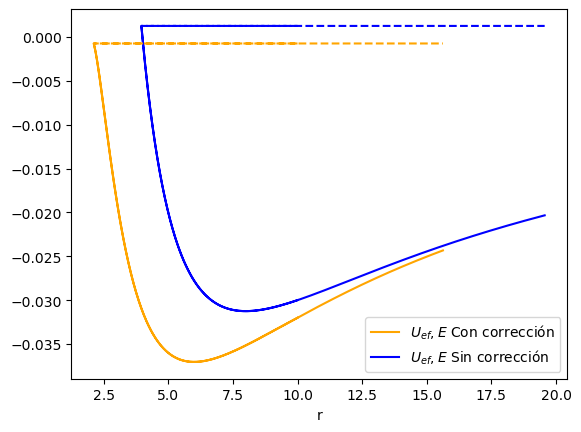

In [20]:
xp3_rel = np.array(xp3_rel)
yp3_rel = np.array(yp3_rel)
xp3_newt = np.array(xp3_newt)
yp3_newt = np.array(yp3_newt)

r_rel = np.sqrt(xp3_rel**2+yp3_rel**2)
r_newt = np.sqrt(xp3_newt**2+yp3_newt**2)

# Potenciales efectivos
plt.plot(r_rel, U3_rel, label="$U_{ef},E$ Con corrección", color="orange")
plt.plot(r_newt, U3_newt, label="$U_{ef},E$ Sin corrección", color="b")

# Energías
plt.plot(r_rel, E3_rel, "--", color="orange")
plt.plot(r_newt, E3_newt, "b--")

plt.legend()
plt.xlabel("r")
plt.show()

**Interpretación de las órbitas a partir de los potenciales efectivos y las energías:** notamos ahora que en ambos casos la energía mecánica de la partícula está por encima de la rama derecha del potencial. Esto es, ambos potenciales propician que la partícula se escape del tirón gravitacional del agujero negro. No obstante, mientras que la dinámica clásica establece, como es sabido, que la excentricidad de la órbita de la partícula será superior a la unidad y por tanto la órbita será una hipérbola, la corrección relativista introduce el mismo resultado con la variación de que la partícula sí completa ahora una revolución alrededor del atractor antes de salir despedida.